# The escalated case: can Monday's deck pack be trusted, part by part?

**Week 2, Friday. The escalated case, alone.**

> **The client asks.** "Build me the file I open on Monday: the tree by segment for both quarters, the
> protect list with the lookup, and the front-page number with its trend. I will change things in the
> room. Tell me what I can trust it for."
>
> Meera's chief of staff, Kalpa Retail

**Who needs the answer.** The chief of staff opens this file in front of Meera and her directors on
Monday. A number that does not tie, a lookup that answers with a neighbour, or a card without its
period goes into the meeting's decisions, and the release note is what tells the chief of staff which
parts to rely on.

**The questions on the way.** Five parts, each a question: does the tree tie; does the list hold the
right fifty and does the lookup say when an id is missing; does the card carry its period, comparison
and base; what ships and what, if anything, is held; do the numbers agree a second way.

You have two exports in `../data/`: the customer table, one row per customer who ordered
between April and September 2026 with that customer's orders and revenue summed, and the raw export,
one row per payment with the order's amount repeated on each. The warehouse, which Monday's queries
read, holds one row per order and is the source of truth. Finance's control totals, which the warehouse
reproduces, are 538 orders and Rs 10,00,00,000 for Q1 (April to June 2026) and 462 orders and
Rs 9,84,00,000 for Q2 (July to September 2026). Revenue is booked order value in rupees. C-0195 is a
Retail-Plus member who placed no orders in the two quarters.

Ten lettered `TODO` markers across five parts, each filled with the line of the key's letter; the checks after each part test what those lines computed, and each part ends on why the other letters fail. This is the executed solution.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv
import pandas as pd

DATA = kit.data_dir()
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Rupees the way Kalpa's finance team reads them: crore, lakh, or rupees in full."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


def change(before, after):
    """The change from before to after, measured on before, in percent."""
    return (after - before) / before * 100

table = pd.read_csv(DATA / "C2_W02_D05_customer_table_STUDENT.csv")

raw = pd.read_csv(DATA / "C2_W02_D05_raw_export_STUDENT.csv", keep_default_na=False)
raw["quarter"] = raw["order_date"].str[5:7].astype(int).map(lambda m: "Q1" if m <= 6 else "Q2")


def warehouse(query):
    """Ask the Kalpa warehouse itself, the source of truth every sheet ties back to."""
    return [{k: (int(v) if hasattr(v, "as_integer_ratio") and not isinstance(v, float) else v)
             for k, v in row.items()} for row in kit.sql(query)]

FINANCE = {"Q1": (538, 10_00_00_000), "Q2": (462, 9_84_00_000)}   # Finance's control totals: orders, rupees
print(len(table), "customer rows and", f"{len(raw):,}", "export rows loaded")

300 customer rows and 1,450 export rows loaded


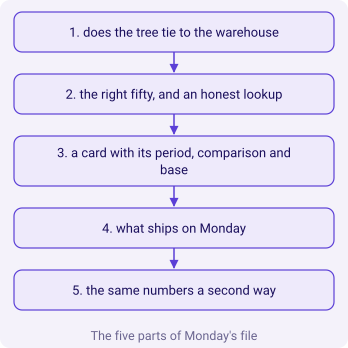

In [2]:
kit.vflow(["1. does the tree tie to the warehouse", "2. the right fifty, and an honest lookup",
           "3. a card with its period, comparison and base", "4. what ships on Monday",
           "5. the same numbers a second way"], title="The five parts of Monday's file")

## Part 1. Does your tree for both quarters tie to the warehouse to the rupee?

Used at work on every tree a director sees, which has to reproduce the number Finance owns before anyone
slices it.

Its leaves count customers, orders and rupees for each segment and quarter.

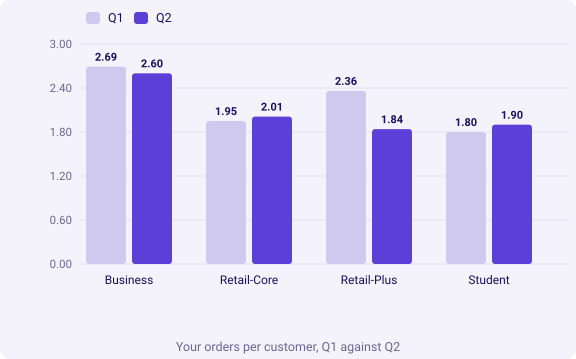

In [3]:
# TODO 1. Which line leaves exactly one row per order?
#   a) orders = raw.drop_duplicates()
#   b) orders = raw.drop_duplicates("customer_id")
#   c) orders = raw.drop_duplicates("order_id")
#   d) orders = raw[raw["paid_amount"] > 0]
orders = raw.drop_duplicates("order_id")

# TODO 2. How are customers counted in each segment and quarter?
#   a) ("customer_id", "count")
#   b) ("customer_id", "nunique")
#   c) ("order_id", "nunique")
#   d) ("customer_id", "size")
tree = orders.groupby(["segment", "quarter"]).agg(customers=("customer_id", "nunique"),
                                                  orders=("order_id", "size"),
                                                  revenue=("order_amount", "sum"))
tree["orders_per_customer"] = tree["orders"] / tree["customers"]
tree["revenue_per_order"] = tree["revenue"] / tree["orders"]
yours = orders.groupby("quarter").agg(n=("order_id", "size"), revenue=("order_amount", "sum"))   # your two quarters
kit.columns(SEGMENTS, [(q, [round(tree.loc[(s, q), "orders_per_customer"], 2) for s in SEGMENTS]) for q in ["Q1", "Q2"]],
            fmt=lambda v: f"{v:.2f}", title="Your orders per customer, Q1 against Q2")

In [4]:
kit.check("your quarters tie to Finance's control totals, orders and rupees",
          all((int(yours.loc[q, "n"]), int(yours.loc[q, "revenue"])) == FINANCE[q] for q in FINANCE))
pairs = warehouse("SELECT o.quarter, o.customer_id FROM orders o JOIN customers c USING (customer_id) "
                  "WHERE c.segment = 'Retail-Plus' GROUP BY o.quarter, o.customer_id")
kit.check("your Retail-Plus customer counts match the warehouse's",
          all(int(tree.loc[("Retail-Plus", q), "customers"]) == sum(r["quarter"] == q for r in pairs) for q in FINANCE))

**Why the other letters fail.** TODO 1: a keeps the 400 instalment orders twice, since their two rows differ in paid_amount; b keeps one order per customer; d drops the unpaid orders and keeps every repeat. TODO 2: a and d count rows, so a customer with three orders counts three times; c counts orders.

## Part 2. Does your protect list hold the right fifty, and does your lookup say when an id is missing?

Used at work wherever a list a manager acts on, or a lookup a director types into, is read aloud in a
room where nobody can see the formula.

The list comes from the customer table, one row per customer who ordered, since that is the table the
chief of staff refreshes.

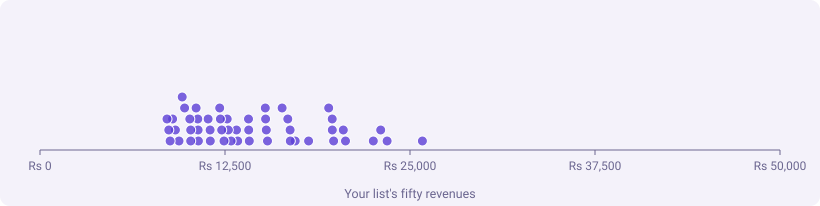

In [5]:
plus = table[table["segment"] == "Retail-Plus"]

# TODO 3. Which line gives the fifty Retail-Plus members with the highest revenue?
#   a) protect = table.nlargest(50, "revenue")
#   b) protect = plus.nsmallest(50, "revenue")
#   c) protect = plus.head(50)
#   d) protect = plus.nlargest(50, "revenue")
protect = plus.nlargest(50, "revenue")

by_id = table.set_index("customer_id")
# TODO 4. Which lookup returns a member's revenue, or a sentence when the id is not in the table?
#   a) lookup = lambda m: by_id["revenue"].get(m, "not in the table")
#   b) lookup = lambda m: by_id["revenue"].iloc[by_id.index.searchsorted(m, "right") - 1]
#   c) lookup = lambda m: by_id["revenue"].iloc[0]
#   d) lookup = lambda m: by_id["revenue"].get(m, 0)
lookup = lambda m: by_id["revenue"].get(m, "not in the table")
kit.strip(protect["revenue"].tolist(), fmt=kit.rupees, title="Your list's fifty revenues")

In [6]:
outside = plus[~plus["customer_id"].isin(protect["customer_id"])]
kit.check("your list is fifty Retail-Plus members, none below anyone left off",
          len(protect) == 50 and set(protect["segment"]) == {"Retail-Plus"} and protect["revenue"].min() >= outside["revenue"].max())
kit.check("your lookup finds a member who is in the table", lookup("C-0152") == int(table.loc[table["customer_id"] == "C-0152", "revenue"].sum()))
kit.check("your lookup answers C-0195, who placed no orders, with a sentence and no number", isinstance(lookup("C-0195"), str))

**Why the other letters fail.** TODO 3: a ranks every segment together, so 39 Business buyers take most of the places; b keeps the fifty lowest; c keeps the first fifty rows in id order, which is no ranking. TODO 4: b is an approximate match, returning the member just below a missing id, which is VLOOKUP with its fourth argument left out; c returns the first member for every id; d answers a missing id with 0, which reads as a member who spent nothing.

## Part 3. Does your front-page card carry its period, its comparison and its base, for any scope a director picks?

Used at work on every front page, read in two minutes by people who read nothing else.

The card's scope (all segments, all except Business, Retail-Plus) is the input a director changes.

In [7]:
seg_q = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum")
SCOPES = {"All segments": SEGMENTS, "All except Business": ["Retail-Core", "Retail-Plus", "Student"], "Retail-Plus": ["Retail-Plus"]}
company_q2 = int(seg_q["Q2"].sum())


def card(scope):
    q1, q2 = int(seg_q.loc[SCOPES[scope], "Q1"].sum()), int(seg_q.loc[SCOPES[scope], "Q2"].sum())
    # TODO 5. Which is the change from Q1 to Q2?
    #   a) (q2 - q1) / q2 * 100
    #   b) (q1 - q2) / (q1 + q2) * 100
    #   c) q2 / q1 * 100
    #   d) (q2 - q1) / q1 * 100
    change = (q2 - q1) / q1 * 100
    # TODO 6. Which share goes beside the number?
    #   a) q2 / company_q2 * 100
    #   b) q2 / (q1 + q2) * 100
    #   c) (q2 - q1) / company_q2 * 100
    #   d) q2 / int(seg_q.sum().sum()) * 100
    share = q2 / company_q2 * 100
    return {"scope": scope, "Q1": q1, "Q2": q2, "change": change, "share": share}


kit.table(["Scope", "Q2", "Change on Q1", "Share of company revenue"],
          [(s, money(card(s)["Q2"]), f"{card(s)['change']:+.1f}%", f"{card(s)['share']:.1f}%") for s in SCOPES])

Scope,Q2,Change on Q1,Share of company revenue
All segments,Rs 9.84 crore,-1.6%,100.0%
All except Business,Rs 8.15 lakh,-17.3%,0.8%
Retail-Plus,Rs 4.13 lakh,-29.4%,0.4%


In [8]:
kit.check("your Retail-Plus change matches chapter 4's, which the warehouse reproduced", round(card("Retail-Plus")["change"], 1) == -29.4)
kit.check("your shares match chapter 4's, for all segments and for Retail-Plus",
          round(card("All segments")["share"], 1) == 100.0 and round(card("Retail-Plus")["share"], 2) == 0.42)

**Why the other letters fail.** TODO 5: a divides by the current quarter, which reads Retail-Plus down 41.7 percent where it fell 29.4; b measures the fall against both quarters together, a base no card names; c is a ratio, about 98 for all segments and 71 for Retail-Plus, that a card would misprint as a percentage. TODO 6: b shares out the scope's own two quarters; c is the change as a share of company revenue, a different number from the scope's share; d divides one quarter by the company's two quarters, a base from a different period, so every share reads about half what it is and all segments come to 49.6 percent.

## Part 4. What ships on Monday, and what, if anything, is held?

Used at work in every release note, which says what a stakeholder can rely on, what waits, and why.

The tree was checked in part 1; the protect list was built from the customer table, a different
export.

In [9]:
once = raw.drop_duplicates("order_id")
# TODO 7. Which comparison says whether the list's source table ties?
#   a) source_ties = len(table) == 300
#   b) source_ties = int(protect["revenue"].sum()) == int(plus.nlargest(50, "revenue")["revenue"].sum())
#   c) source_ties = (int(table["orders"].sum()), int(table["revenue"].sum())) == (len(once), int(once["order_amount"].sum()))
#   d) source_ties = int(table["revenue"].sum()) > int(seg_q["Q2"].sum())
source_ties = (int(table["orders"].sum()), int(table["revenue"].sum())) == (len(once), int(once["order_amount"].sum()))

checks = {"tree ties": all((int(yours.loc[q, "n"]), int(yours.loc[q, "revenue"])) == FINANCE[q] for q in FINANCE),
          "source ties": source_ties,
          "lookup honest": isinstance(lookup("C-0195"), str)}
needs = {"tree": ["tree ties"], "front page": ["tree ties"], "protect list": ["source ties", "lookup honest"]}
# TODO 8. Which rule turns any set of checks into Monday's release?
#   a) decide = lambda checks: {part: ("ship" if sum(checks.values()) >= 2 else "hold") for part in needs}
#   b) decide = lambda checks: {part: ("ship" if all(checks[c] for c in needs[part]) else "hold") for part in needs}
#   c) decide = lambda checks: {part: ("ship" if all(checks.values()) else "hold") for part in needs}
#   d) decide = lambda checks: {part: "ship" for part in needs}  # every number here is a formula, so all of it recalculates
decide = lambda checks: {part: ("ship" if all(checks[c] for c in needs[part]) else "hold") for part in needs}
release = decide(checks)
print(release)

{'tree': 'ship', 'front page': 'ship', 'protect list': 'hold'}


In [10]:
who_ordered = warehouse("SELECT count(DISTINCT customer_id) AS n FROM orders")[0]["n"]
kit.check("your source check reaches the warehouse's verdict on the customer table", source_ties == (len(table) == who_ordered))
invented = [({"tree ties": True, "source ties": True, "lookup honest": False}, {"tree": "ship", "front page": "ship", "protect list": "hold"}),
            ({"tree ties": False, "source ties": True, "lookup honest": True}, {"tree": "hold", "front page": "hold", "protect list": "ship"}),
            ({"tree ties": True, "source ties": True, "lookup honest": True}, {"tree": "ship", "front page": "ship", "protect list": "ship"})]
kit.check("your rule gives the right release on three invented sets of checks", all(decide(c) == want for c, want in invented))

**Why the other letters fail.** TODO 7: a, b and d each read True on this table, so the list would ship on a source nobody compared with anything outside it. a counts rows against a number the table itself gave; b compares the list with itself; d compares a half-year with a quarter. TODO 8: a ships every part when two checks pass, whatever sits behind each part; c holds every part when one check fails; d ships everything, which confuses recalculating with being right.

## Part 5. Do your numbers agree when reached a second way?

Used at work on every number that matters, which is reached twice by routes that could disagree.

Here the warehouse is the second route twice: its own query for the two quarters, and its revenue for the
list's Mumbai members against the foot a filtered list shows.

Quarter,Your tree,The query you picked
Q1,"Rs 10,00,00,000","Rs 10,00,00,000"
Q2,"Rs 9,84,00,000","Rs 9,84,00,000"


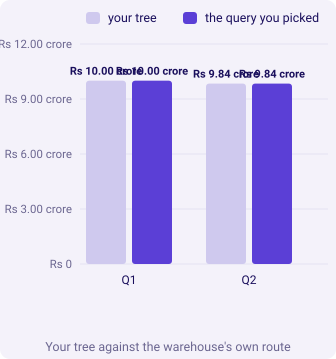

In [11]:
visible = protect["city"] == "Mumbai"
# TODO 9. Which total is what SUBTOTAL(109) shows at the foot of the list filtered to Mumbai?
#   a) foot = int(protect["revenue"].sum())
#   b) foot = int(protect.loc[visible, "revenue"].sum())
#   c) foot = int(protect.loc[~visible, "revenue"].sum())
#   d) foot = int(table.loc[table["city"] == "Mumbai", "revenue"].sum())
foot = int(protect.loc[visible, "revenue"].sum())

# TODO 10. Which query is the warehouse's own route to the two quarters of booked revenue?
#   a) "SELECT quarter, sum(amount) AS revenue FROM orders GROUP BY quarter"
#   b) "SELECT o.quarter, sum(p.amount) AS revenue FROM payments p JOIN orders o USING (order_id) GROUP BY o.quarter"
#   c) "SELECT quarter, count(*) AS revenue FROM orders GROUP BY quarter"
#   d) "SELECT quarter, sum(amount) AS revenue FROM orders WHERE status = 'delivered' GROUP BY quarter"
query = "SELECT quarter, sum(amount) AS revenue FROM orders GROUP BY quarter"
second = {r["quarter"]: int(r["revenue"]) for r in warehouse(query)}
kit.table(["Quarter", "Your tree", "The query you picked"], [(q, kit.rupees(int(yours.loc[q, "revenue"])), kit.rupees(second[q])) for q in ["Q1", "Q2"]])
kit.columns(["Q1", "Q2"], [("your tree", [int(yours.loc[q, "revenue"]) for q in ["Q1", "Q2"]]), ("the query you picked", [second[q] for q in ["Q1", "Q2"]])],
            fmt=money, title="Your tree against the warehouse's own route")

In [12]:
listed = "', '".join(protect["customer_id"])
w_mumbai = warehouse("SELECT coalesce(sum(o.amount), 0) AS revenue FROM orders o JOIN customers c USING (customer_id) "
                     f"WHERE c.city = 'Mumbai' AND o.customer_id IN ('{listed}')")[0]["revenue"]
kit.check("your foot equals the warehouse's revenue for the list's Mumbai members", foot == int(w_mumbai))
kit.check("the query you picked agrees with your tree, both quarters", all(second[q] == int(yours.loc[q, "revenue"]) for q in ["Q1", "Q2"]))

**Why the other letters fail.** TODO 9: a is SUM, which adds the rows the filter hid; c adds exactly the hidden rows; d adds every Mumbai customer in every segment. TODO 10: b adds every payment row as the gateway posted it, double posts included, so Q1 reads Rs 10,00,17,000, above booked, and Q2 leaves out the orders nobody paid for; c counts orders; d leaves out returned and cancelled orders, which booked revenue counts.

## What do you post, and what can the chief of staff trust?

Post your ten letters in order as one line, then two sentences to the chief of staff: what Monday's
file can be relied on for, and anything held, with its reason. The key is `cbdadacbba`.

In [13]:
kit.check_summary()